
DATA CHECK
Pressure points: 262812
Temperature points: 262812
Valid temperature: 262812

Temperature statistics:
count    262812.000000
mean         25.361440
std           1.345237
min          22.874286
25%          24.211429
50%          25.451429
75%          26.650000
max          27.111429
Name: Temp, dtype: float64

MERGED DATA
Merged points: 262812

Pressure:
count    262812.000000
mean          4.159018
std           0.146600
min           3.468000
25%           4.085000
50%           4.139000
75%           4.220000
max           4.923000
Name: PG5, dtype: float64

Temperature [ºC]:
count    262812.000000
mean         25.361440
std           1.345235
min          22.874286
25%          24.211429
50%          25.451429
75%          26.650000
max          27.111429
Name: Temp, dtype: float64

P/T [bar/K]:
count    262812.000000
mean          0.013932
std           0.000477
min           0.011555
25%           0.013720
50%           0.013900
75%           0.014120
max           

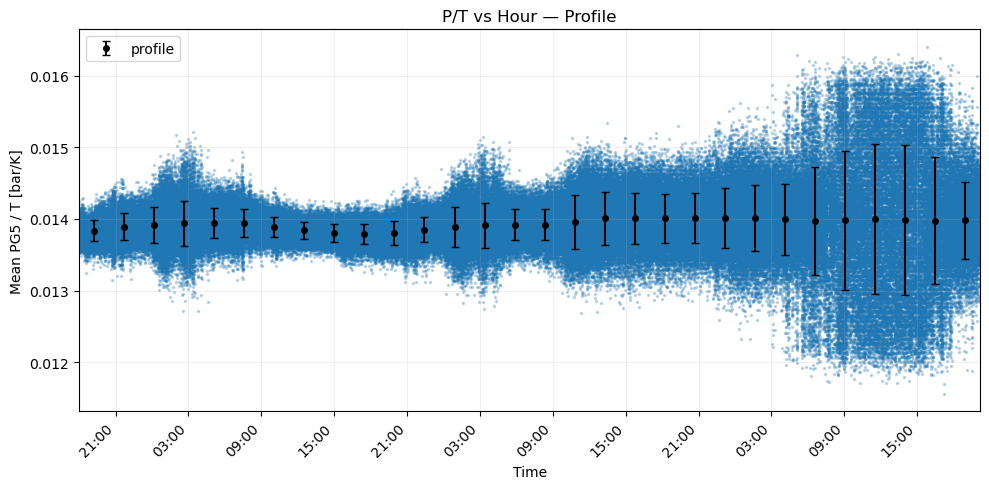

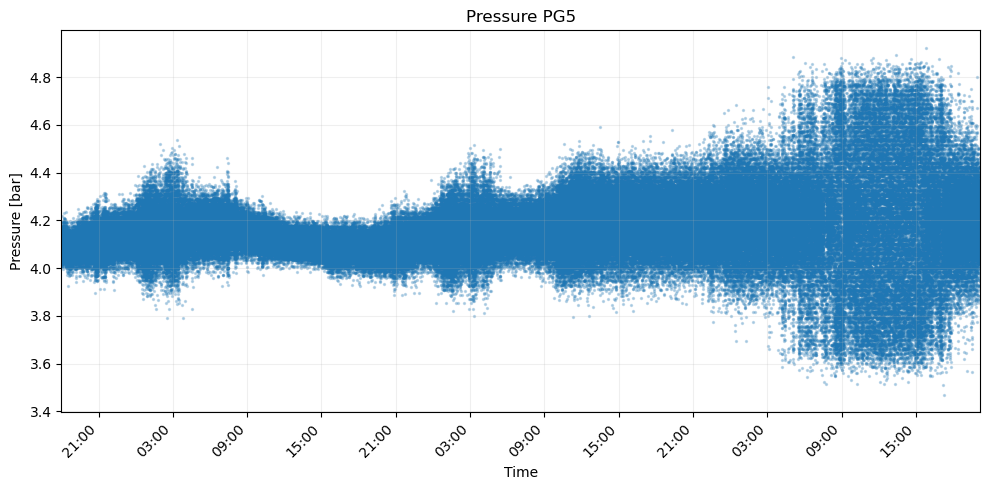

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. FILES
# ============================================================

pressure_paths = [
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-07.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-08.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-09.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-10.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-11.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-12.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-13.txt'
]

temp_paths = [
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-07.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-08.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-09.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-10.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-11.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-12.txt',
    '/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-13.txt'
]


# ============================================================
# 2. READ PRESSURE
# ============================================================

pressure_list = []

for path in pressure_paths:

    df = pd.read_csv(path,sep='\t',skiprows = 1, header = 0, encoding='latin-1')
    pressure_list.append(df)

data = pd.concat(pressure_list, ignore_index=True)


# ============================================================
# 3. READ TEMPERATURE
# ============================================================

temp_list = []

for path in temp_paths:

    df = pd.read_csv(path, sep='\t',skiprows=1, header=0, encoding='latin-1')
    temp_list.append(df)

data_temps = pd.concat(temp_list, ignore_index=True)


# ============================================================
# 4. PRESSURE -> NUMERIC
# ============================================================

data['PG5'] = pd.to_numeric(data['PG5'].astype(str).str.replace(',', '.', regex=False), errors='coerce')


# ============================================================
# 5. DATETIME
# ============================================================

def make_datetime(df):

    date = pd.to_datetime(
        df['Date'],
        dayfirst=True,
        errors='coerce'
    )

    hour = pd.to_datetime(
        df['Hour'],
        errors='coerce'
    )

    datetime = (
        date
        + pd.to_timedelta(hour.dt.hour, unit='h')
        + pd.to_timedelta(hour.dt.minute, unit='m')
        + pd.to_timedelta(hour.dt.second, unit='s')
    )

    return datetime


data['datetime'] = make_datetime(data)

data_temps['datetime'] = make_datetime(data_temps)


# ============================================================
# 6. TEMPERATURE COLUMNS
# ============================================================

temp_columns = [
    'Pt100_3',
    'Pt100_7',
    'Pt100_9',
    'Pt100_11',
    'Pt100_13',
    'Pt100_15',
    'Pt100_16'
]

# Pt100_4 NO se incluye porque aparece como NaN.


# ============================================================
# 7. CONVERT ºC STRINGS -> FLOAT
# ============================================================

for col in temp_columns:

    data_temps[col] = pd.to_numeric(
        data_temps[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace('ºC', '', regex=False)
        .str.replace('°C', '', regex=False)
        .str.strip(),
        errors='coerce'
    )


# ============================================================
# 8. TEMPERATURE MEAN
# ============================================================

data_temps['Temp'] = data_temps[
    temp_columns
].mean(axis=1, skipna=True)


# ============================================================
# 9. SORT
# ============================================================

data = data.sort_values(
    'datetime'
).reset_index(drop=True)

data_temps = data_temps.sort_values(
    'datetime'
).reset_index(drop=True)


# ============================================================
# 10. TIME WINDOW
# ============================================================

inicio = pd.Timestamp(
    '2026-09-10 18:00:00'
)

fin = pd.Timestamp(
    '2026-09-13 20:1' \
    '0:00'
)


# ============================================================
# 11. SELECT WINDOW
# ============================================================

pressure_window = data[
    (data['datetime'] >= inicio) &
    (data['datetime'] <= fin)
].copy()

temp_window = data_temps[
    (data_temps['datetime'] >= inicio) &
    (data_temps['datetime'] <= fin)
].copy()


# ============================================================
# 12. CHECK
# ============================================================

print('\n======================================')
print('DATA CHECK')
print('======================================')

print(
    'Pressure points:',
    len(pressure_window)
)

print(
    'Temperature points:',
    len(temp_window)
)

print(
    'Valid temperature:',
    temp_window['Temp'].notna().sum()
)

print(
    '\nTemperature statistics:'
)

print(
    temp_window['Temp'].describe()
)


# ============================================================
# 13. MERGE
# ============================================================

pressure_window = pressure_window.sort_values(
    'datetime'
)

temp_window = temp_window.sort_values(
    'datetime'
)


merged_ventana = pd.merge_asof(
    pressure_window[
        ['datetime', 'PG5']
    ],
    temp_window[
        ['datetime', 'Temp']
    ],
    on='datetime',
    direction='nearest',
    tolerance=pd.Timedelta('30s')
)


# ============================================================
# 14. REMOVE NaN
# ============================================================

merged_ventana = merged_ventana.dropna(
    subset=[
        'PG5',
        'Temp'
    ]
).copy()


# ============================================================
# 15. CALCULATE P/T
# ============================================================

merged_ventana['P_over_T_K'] = (
    merged_ventana['PG5']
    /
    (
        merged_ventana['Temp']
        + 273.15
    )
)


# ============================================================
# 16. FINAL CHECK
# ============================================================

print('\n======================================')
print('MERGED DATA')
print('======================================')

print(
    'Merged points:',
    len(merged_ventana)
)

print(
    '\nPressure:'
)

print(
    merged_ventana['PG5'].describe()
)

print(
    '\nTemperature [ºC]:'
)

print(
    merged_ventana['Temp'].describe()
)

print(
    '\nP/T [bar/K]:'
)

print(
    merged_ventana['P_over_T_K'].describe()
)


# ============================================================
# ============================================================
# 17. SCATTER PLOT
# ============================================================
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.scatter(
    merged_ventana['datetime'],
    merged_ventana['P_over_T_K'],
    s=2,
    alpha=0.25
)

ax.set_xlim(
    inicio,
    fin
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_xlabel('Time')
ax.set_ylabel('PG5 / T [bar/K]')
ax.set_title('P/T vs Hour — Scatter')

ax.grid(
    alpha=0.2
)

plt.tight_layout()


# ============================================================
# ============================================================
# 19. PROFILE
# ============================================================
# ============================================================

n_bins = 30

time_bins = pd.date_range(
    start=inicio,
    end=fin,
    periods=n_bins + 1
)


merged_ventana['time_bin'] = pd.cut(
    merged_ventana['datetime'],
    bins=time_bins
)


profile = (
    merged_ventana
    .groupby(
        'time_bin',
        observed=True
    )['P_over_T_K']
    .agg(
        mean='mean',
        std='std',
        count='count'
    )
    .reset_index()
)


# Centro de cada bin
profile['time'] = profile[
    'time_bin'
].apply(
    lambda x: x.mid
)


# ============================================================
# 20. PROFILE PLOT
# ============================================================


ax.errorbar(
    profile['time'],
    profile['mean'],
    yerr=profile['std'],
    fmt='o',
    markersize=4,
    capsize=3,
    color = 'black',
    label = 'profile'
)

ax.set_xlim(
    inicio,
    fin
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_xlabel('Time')
ax.set_ylabel(
    'Mean PG5 / T [bar/K]'
)

ax.set_title(
    'P/T vs Hour — Profile'
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
ax.legend()
plt.show()

# ============================================================
# ============================================================
# 17. SCATTER PLOT
# ============================================================
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.scatter(
    merged_ventana['datetime'],
    merged_ventana['PG5'],
    s=2,
    alpha=0.25
)

ax.set_xlim(
    inicio,
    fin
)

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%H:%M')
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)

ax.set_xlabel('Time')
ax.set_ylabel('Pressure [bar]')
ax.set_title('Pressure PG5')

ax.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()



DATA CHECK
Pressure points: 262812
Temperature points: 262812
Valid temperature: 262812

Temperature statistics:
count    262812.000000
mean         25.361440
std           1.345237
min          22.874286
25%          24.211429
50%          25.451429
75%          26.650000
max          27.111429
Name: Temp, dtype: float64

MERGED DATA
Merged points: 262812

Pressure:
count    262812.000000
mean          4.159018
std           0.146600
min           3.468000
25%           4.085000
50%           4.139000
75%           4.220000
max           4.923000
Name: PG5, dtype: float64

Temperature [ºC]:
count    262812.000000
mean         25.361440
std           1.345235
min          22.874286
25%          24.211429
50%          25.451429
75%          26.650000
max          27.111429
Name: Temp, dtype: float64

P/T [bar/K]:
count    262812.000000
mean          0.013932
std           0.000477
min           0.011555
25%           0.013720
50%           0.013900
75%           0.014120
max           

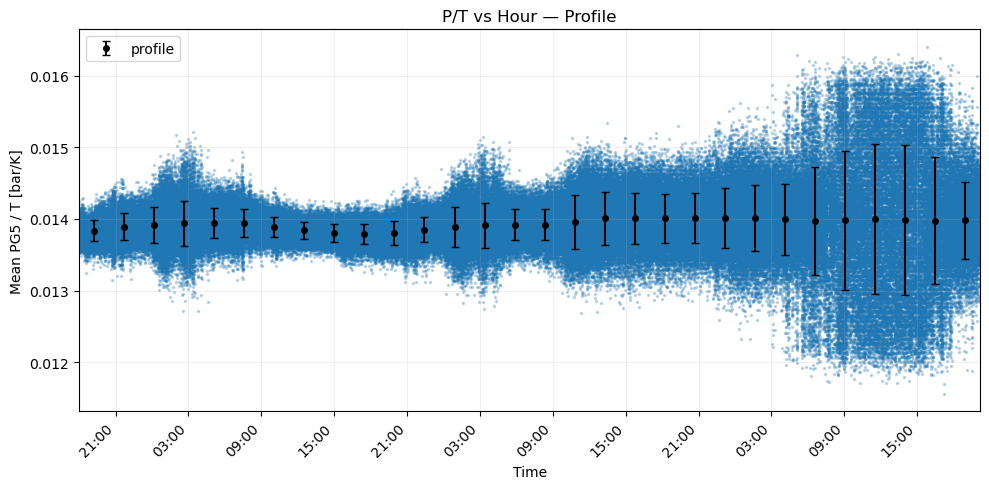

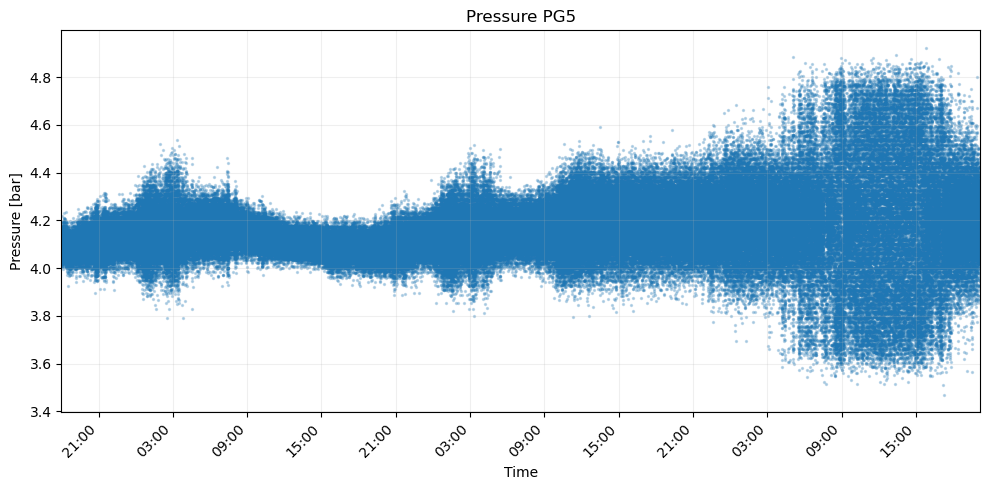

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pressure_paths=['/Users/pablovazquez/Downloads/DEMO_GAS_Pressure_Data_Report_2026-09-%02d.txt'%i for i in range(7,14)]
temp_paths=['/Users/pablovazquez/Downloads/DEMO_GAS_TEMP_Data_Report_2026-09-%02d.txt'%i for i in range(7,14)]

pressure_list=[]

for path in pressure_paths:
    df=pd.read_csv(path,sep='\t',skiprows=1,header=0,encoding='latin-1')
    pressure_list.append(df)

data=pd.concat(pressure_list,ignore_index=True)

temp_list=[]

for path in temp_paths:
    df=pd.read_csv(path,sep='\t',skiprows=1,header=0,encoding='latin-1')
    temp_list.append(df)

data_temps=pd.concat(temp_list,ignore_index=True)
data['PG5']=pd.to_numeric(data['PG5'].astype(str).str.replace(',','.',regex=False),errors='coerce')

def make_datetime(df):
    date=pd.to_datetime(df['Date'],dayfirst=True,errors='coerce')
    hour=pd.to_datetime(df['Hour'],errors='coerce')
    return date+pd.to_timedelta(hour.dt.hour,unit='h')+pd.to_timedelta(hour.dt.minute,unit='m')+pd.to_timedelta(hour.dt.second,unit='s')

data['datetime']=make_datetime(data)
data_temps['datetime']=make_datetime(data_temps)

temp_columns=['Pt100_3','Pt100_7','Pt100_9','Pt100_11','Pt100_13','Pt100_15','Pt100_16']

for col in temp_columns:
    data_temps[col]=pd.to_numeric(data_temps[col].astype(str).str.replace(',','.',regex=False).str.replace('ºC','',regex=False).str.replace('°C','',regex=False).str.strip(),errors='coerce')

data_temps['Temp']=data_temps[temp_columns].mean(axis=1,skipna=True)
data=data.sort_values('datetime').reset_index(drop=True)
data_temps=data_temps.sort_values('datetime').reset_index(drop=True)

inicio=pd.Timestamp('2026-09-10 18:00:00')
fin=pd.Timestamp('2026-09-13 20:10:00')

pressure_window=data[(data['datetime']>=inicio)&(data['datetime']<=fin)].copy()
temp_window=data_temps[(data_temps['datetime']>=inicio)&(data_temps['datetime']<=fin)].copy()

print('\n======================================')
print('DATA CHECK')
print('======================================')
print('Pressure points:',len(pressure_window))
print('Temperature points:',len(temp_window))
print('Valid temperature:',temp_window['Temp'].notna().sum())
print('\nTemperature statistics:')
print(temp_window['Temp'].describe())

pressure_window=pressure_window.sort_values('datetime')
temp_window=temp_window.sort_values('datetime')

merged_ventana=pd.merge_asof(pressure_window[['datetime','PG5']],temp_window[['datetime','Temp']],on='datetime',direction='nearest',tolerance=pd.Timedelta('30s'))
merged_ventana=merged_ventana.dropna(subset=['PG5','Temp']).copy()
merged_ventana['P_over_T_K']=merged_ventana['PG5']/(merged_ventana['Temp']+273.15)

print('\n======================================')
print('MERGED DATA')
print('======================================')
print('Merged points:',len(merged_ventana))
print('\nPressure:')
print(merged_ventana['PG5'].describe())
print('\nTemperature [ºC]:')
print(merged_ventana['Temp'].describe())
print('\nP/T [bar/K]:')
print(merged_ventana['P_over_T_K'].describe())

fig,ax=plt.subplots(figsize=(10,5))

ax.scatter(merged_ventana['datetime'],merged_ventana['P_over_T_K'],s=2,alpha=0.25)
ax.set_xlim(inicio,fin)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.get_xticklabels(),rotation=45,ha='right')
ax.set_xlabel('Time')
ax.set_ylabel('PG5 / T [bar/K]')
ax.set_title('P/T vs Hour — Scatter')
ax.grid(alpha=0.2)
plt.tight_layout()

n_bins=30
time_bins=pd.date_range(start=inicio,end=fin,periods=n_bins+1)
merged_ventana['time_bin']=pd.cut(merged_ventana['datetime'],bins=time_bins)
profile=merged_ventana.groupby('time_bin',observed=True)['P_over_T_K'].agg(mean='mean',std='std',count='count').reset_index()
profile['time']=profile['time_bin'].apply(lambda x:x.mid)

ax.errorbar(profile['time'],profile['mean'],yerr=profile['std'],fmt='o',markersize=4,capsize=3,color='black',label='profile')
ax.set_xlim(inicio,fin)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.get_xticklabels(),rotation=45,ha='right')
ax.set_xlabel('Time')
ax.set_ylabel('Mean PG5 / T [bar/K]')
ax.set_title('P/T vs Hour — Profile')
ax.grid(alpha=0.2)
plt.tight_layout()
ax.legend()
plt.show()

fig,ax=plt.subplots(figsize=(10,5))
ax.scatter(merged_ventana['datetime'],merged_ventana['PG5'],s=2,alpha=0.25)
ax.set_xlim(inicio,fin)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(ax.get_xticklabels(),rotation=45,ha='right')
ax.set_xlabel('Time')
ax.set_ylabel('Pressure [bar]')
ax.set_title('Pressure PG5')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()